# T4.3 — KNN hướng B: tìm sản phẩm tương đồng

**Bài toán.** Với một sản phẩm truy vấn, tìm k sản phẩm gần nhất trong không gian đặc trưng hành vi A7 đã chuẩn hóa
(Euclidean). KNN ở đây là **tìm láng giềng**, không phải phân loại có nhãn, nên không cần tạo nhãn và rủi ro rò rỉ dữ liệu thấp.

**Đánh giá.** *Category agreement@k* = tỷ lệ láng giềng có cùng `category_code` với sản phẩm truy vấn.
Đặc trưng **không** chứa category nên đây là tín hiệu độc lập. Truy vấn: sản phẩm có `category_code`, lấy mẫu theo seed.
Baseline: k sản phẩm ngẫu nhiên; k sản phẩm nhiều views nhất. Khoảng tin cậy 95% bằng bootstrap trên tập truy vấn.
Nếu mô hình không vượt baseline thì ghi nhận là **kết quả âm**, không chỉnh để “đẹp”.

**Spark LSH.** `BucketedRandomProjectionLSH.approxNearestNeighbors` (láng giềng xấp xỉ) được đo recall@10 so với KNN chính xác.
KNN chính xác chạy bằng numpy trên driver vì bảng đặc trưng sau lọc nhỏ (vài chục nghìn dòng).

## 1. Tham số

In [1]:
import sys, json, time
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))
import ml_common as mc

TAG = "d2"
FEATURES_RUN_ID = mc.pipeline_run_id(TAG, "features")
KS, QUERIES, LSH_QUERIES, SEED = [5, 10, 20], 1000, 50, 21
LSH_BUCKET_LENGTH, LSH_TABLES = 1.0, 5
RUN_ID = mc.new_run_id(TAG)
OUT = f"/data/ecommerce/ml/knn/run_id={RUN_ID}"
LOCAL = mc.RESULTS_ML / RUN_ID
print("features run:", FEATURES_RUN_ID, "| knn run:", RUN_ID)

features run: 20261006-045824-24861e8-d2 | knn run: 20261006-050518-24861e8-d2


In [2]:
spark = mc.session(f"knn-{RUN_ID}")
ENV = mc.environment(spark)
trace = mc.Trace("knn", RUN_ID, {"featuresRunId": FEATURES_RUN_ID, "ks": KS, "queries": QUERIES, "lshQueries": LSH_QUERIES, "seed": SEED})
ENV

{'sparkVersion': '4.0.4',
 'javaVersion': '21.0.12',
 'hadoopClientVersion': '3.4.1',
 'pythonVersion': '3.12.10',
 'master': 'local[2]',
 'driverMemory': '1g',
 'gitSha': '24861e8'}

## 2. Đọc đặc trưng A7, chuẩn hóa như K-Means

In [3]:
import numpy as np, pandas as pd
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.functions import vector_to_array
products = spark.read.parquet(mc.hdfs(f"{mc.FEATURES_ROOT}/run_id={FEATURES_RUN_ID}"))
assert all(c in products.columns for c in mc.FEATURES)
assembled = VectorAssembler(inputCols=mc.FEATURES, outputCol="raw_features").transform(products)
scaled = StandardScaler(inputCol="raw_features", outputCol="features", withMean=True, withStd=True).fit(assembled).transform(assembled).cache()
with trace.stage("collect"):
    table = scaled.select("product_id", "category_code", "views", vector_to_array("features").alias("v")).toPandas()
ids = table.product_id.to_numpy(); codes = table.category_code.fillna("").to_numpy(); views = table.views.to_numpy()
X = np.array(table.v.tolist()); N = len(table)
print(f"Sản phẩm: {N}; có category_code: {(codes != '').sum()}; số chiều: {X.shape[1]}")

[05:05:34] bắt đầu: collect


[05:05:36] xong: collect (1937 ms)
Sản phẩm: 25084; có category_code: 13799; số chiều: 7


## 3. KNN chính xác (Euclidean) cho tập truy vấn lấy mẫu

In [4]:
rng = np.random.default_rng(SEED)
candidates = np.flatnonzero(codes != "")
queries = rng.choice(candidates, size=min(QUERIES, len(candidates)), replace=False)
max_k = max(KS)
with trace.stage("exact_knn"):
    neighbors = np.empty((len(queries), max_k), dtype=int)
    for i, q in enumerate(queries):
        d = ((X - X[q]) ** 2).sum(axis=1); d[q] = np.inf          # bỏ chính nó
        idx = np.argpartition(d, max_k)[:max_k]
        neighbors[i] = idx[np.argsort(d[idx], kind="stable")]
print("Ví dụ 3 truy vấn đầu và 5 láng giềng gần nhất:")
pd.DataFrame([{"query": ids[q], "query_code": codes[q], "rank": r + 1, "neighbor": ids[j], "neighbor_code": codes[j]}
              for i, q in enumerate(queries[:3]) for r, j in enumerate(neighbors[i, :5])])

[05:05:36] bắt đầu: exact_knn


[05:05:38] xong: exact_knn (1966 ms)
Ví dụ 3 truy vấn đầu và 5 láng giềng gần nhất:


,query,query_code,rank,neighbor,neighbor_code
0,12600100,appliances.kitchen.grill,1,1201282,electronics.tablet
1,12600100,appliances.kitchen.grill,2,28704822,apparel.shoes.keds
2,12600100,appliances.kitchen.grill,3,13300825,
3,12600100,appliances.kitchen.grill,4,12706631,
4,12600100,appliances.kitchen.grill,5,32900003,accessories.bag
5,3700094,appliances.environment.vacuum,1,3400040,
6,3700094,appliances.environment.vacuum,2,5600019,
7,3700094,appliances.environment.vacuum,3,2601440,
8,3700094,appliances.environment.vacuum,4,5000245,appliances.sewing_machine
9,3700094,appliances.environment.vacuum,5,3900837,appliances.environment.water_heater


## 4. Category agreement@k so với hai baseline (bootstrap 95%)

In [5]:
def ci(values, resamples=1000):
    values = np.asarray(values, dtype=float)
    means = values[rng.integers(0, len(values), size=(resamples, len(values)))].mean(axis=1)
    return np.percentile(means, [2.5, 97.5]).round(4).tolist()

popular = np.argsort(-views, kind="stable")[: max_k + 1]
rows = []
with trace.stage("evaluate"):
    for k in KS:
        model_scores = [(codes[neighbors[i, :k]] == codes[q]).mean() for i, q in enumerate(queries)]
        random_scores = []
        for q in queries:
            pool = rng.choice(N - 1, size=k, replace=False); pool[pool >= q] += 1
            random_scores.append((codes[pool] == codes[q]).mean())
        popular_scores = [(codes[[p for p in popular if p != q][:k]] == codes[q]).mean() for q in queries]
        for name, scores in [("KNN (mô hình)", model_scores), ("Baseline ngẫu nhiên", random_scores), ("Baseline phổ biến", popular_scores)]:
            rows.append({"k": k, "method": name, "agreement": round(float(np.mean(scores)), 4), "ci95": ci(scores)})
agreement = pd.DataFrame(rows)
agreement.pivot(index="method", columns="k", values="agreement")

[05:05:38] bắt đầu: evaluate


[05:05:38] xong: evaluate (264 ms)


k,5,10,20
method,,,
Baseline ngẫu nhiên,0.0148,0.0129,0.0126
Baseline phổ biến,0.0760,0.0631,0.0696
KNN (mô hình),0.0556,0.0538,0.0530


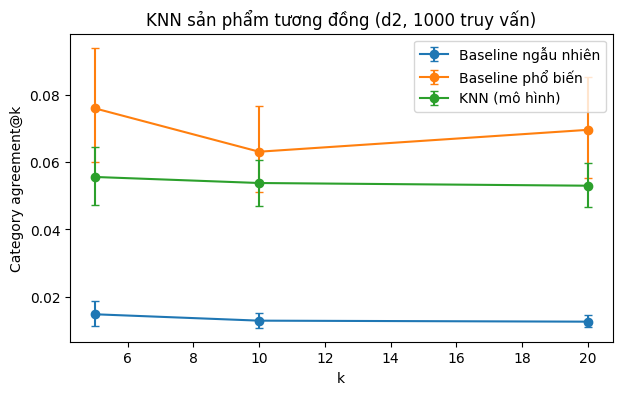

In [6]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(7, 4))
for name, g in agreement.groupby("method"):
    lo = [c[0] for c in g.ci95]; hi = [c[1] for c in g.ci95]
    ax.errorbar(g.k, g.agreement, yerr=[g.agreement - lo, np.array(hi) - g.agreement], marker="o", capsize=3, label=name)
ax.set_xlabel("k"); ax.set_ylabel("Category agreement@k"); ax.set_title(f"KNN sản phẩm tương đồng ({TAG}, {len(queries)} truy vấn)"); ax.legend(); plt.show()

## 5. Spark LSH (láng giềng xấp xỉ): recall@10 so với KNN chính xác

In [7]:
from pyspark.ml.feature import BucketedRandomProjectionLSH
from pyspark.ml.linalg import Vectors
k = 10
with trace.stage("lsh"):
    lsh = BucketedRandomProjectionLSH(inputCol="features", outputCol="hashes", bucketLength=LSH_BUCKET_LENGTH, numHashTables=LSH_TABLES, seed=SEED).fit(scaled)
    recalls = []
    for i, q in enumerate(queries[:LSH_QUERIES]):
        found = {r["product_id"] for r in lsh.approxNearestNeighbors(scaled, Vectors.dense(X[q]), k + 1).select("product_id").collect()} - {ids[q]}
        recalls.append(len(found & set(ids[neighbors[i, :k]])) / k)
lsh_result = {"k": k, "queries": len(recalls), "bucketLength": LSH_BUCKET_LENGTH, "numHashTables": LSH_TABLES, "meanRecall": round(float(np.mean(recalls)), 4), "ci95": ci(recalls)}
lsh_result

[05:05:39] bắt đầu: lsh


[05:05:49] xong: lsh (10211 ms)


{'k': 10,
 'queries': 50,
 'bucketLength': 1.0,
 'numHashTables': 5,
 'meanRecall': 0.998,
 'ci95': [0.994, 1.0]}

## 6. Lưu vết lần chạy

In [8]:
LOCAL.mkdir(parents=True, exist_ok=True)
agreement.to_csv(LOCAL / "knn-agreement.csv", index=False)
pd.DataFrame([{"query_product_id": ids[q], "query_category_code": codes[q], "rank": r + 1, "neighbor_product_id": ids[j], "neighbor_category_code": codes[j]}
              for i, q in enumerate(queries[:20]) for r, j in enumerate(neighbors[i, :5])]).to_csv(LOCAL / "knn-neighbors-sample.csv", index=False)
trace.record["environment"] = ENV
trace.record["metrics"] = {"products": N, "productsWithCategoryCode": int(len(candidates)), "queries": int(len(queries)),
                           "distance": "euclidean on standardized A7 features", "agreement": agreement.to_dict(orient="records"), "lsh": lsh_result}
record = trace.finish(LOCAL)
mc.write_hdfs_json(spark, f"{OUT}/_run.json", record)
print(json.dumps(record["metrics"], indent=2, default=str))
print("Kết quả cục bộ:", LOCAL, "| HDFS:", OUT)

{
  "products": 25084,
  "productsWithCategoryCode": 13799,
  "queries": 1000,
  "distance": "euclidean on standardized A7 features",
  "agreement": [
    {
      "k": 5,
      "method": "KNN (m\u00f4 h\u00ecnh)",
      "agreement": 0.0556,
      "ci95": [
        0.0472,
        0.0646
      ]
    },
    {
      "k": 5,
      "method": "Baseline ng\u1eabu nhi\u00ean",
      "agreement": 0.0148,
      "ci95": [
        0.0114,
        0.0188
      ]
    },
    {
      "k": 5,
      "method": "Baseline ph\u1ed5 bi\u1ebfn",
      "agreement": 0.076,
      "ci95": [
        0.06,
        0.094
      ]
    },
    {
      "k": 10,
      "method": "KNN (m\u00f4 h\u00ecnh)",
      "agreement": 0.0538,
      "ci95": [
        0.047,
        0.0605
      ]
    },
    {
      "k": 10,
      "method": "Baseline ng\u1eabu nhi\u00ean",
      "agreement": 0.0129,
      "ci95": [
        0.0108,
        0.0152
      ]
    },
    {
      "k": 10,
      "method": "Baseline ph\u1ed5 bi\u1ebfn",
      "a

In [9]:
spark.stop()